# G-III calibration from NASA IWG1 in-situ logs

Mirrors the structure of the ER-2 calibration in
`notebooks/calibration/er2/calibration.ipynb`, adapted to the
NASA 520 Gulfstream III data, combining a local
`n520NA_g3_alltracks.csv` delivery with the public NASA ASP
archive (asp-archive.arc.nasa.gov/N520NA, FY2024-FY2026).

The output of this notebook is a paste-ready `NASA_GIII()`
constructor block (§10) calibrated against ~153 airborne sorties spanning 2024-FY2026.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hyplan import ureg
from hyplan.aircraft import load_iwg1, trim_ground_taxi, NASA_GIII

# Shared helpers live one directory up (notebooks/calibration/_common.py).
sys.path.insert(0, str(Path("..").resolve()))
from _common import (
    label_phases, apply_sortie_filters, per_bin, tas_per_bin,
    schedule_pts, evaluate_profile, summary_table,
)

DATA_DIR = Path("../../../data/giii").resolve()

# Phase-label thresholds.  Same defaults as the ER-2 notebook —
# climb/descent gate at 300 fpm separates sustained vertical motion
# from autopilot ±100 ft cruise oscillation.
CLIMB_FPM   = 300.0
DESCENT_FPM = -300.0

# Sortie filters: real flights only.
MIN_DUR_MIN     = 60.0   # below this is taxi / engine run
MAX_DUR_MIN     = 600.0  # above this is multi-day data the splitter glued together
MIN_PEAK_ALT_FT = 25000  # below this is local pattern / test flight, not cruise sortie


## 1. Load + trim ground taxi + phase-label every sortie


In [2]:
sorties = {}
skipped = []
for p in sorted(DATA_DIR.glob("*_*.txt")):
    raw = load_iwg1(p)
    a = trim_ground_taxi(raw)
    a, reason = apply_sortie_filters(
        a, min_dur_min=MIN_DUR_MIN, max_dur_min=MAX_DUR_MIN,
        min_peak_alt_ft=MIN_PEAK_ALT_FT,
    )
    if reason is not None:
        skipped.append((p.stem, reason))
        continue
    sorties[p.stem] = label_phases(a, climb_fpm=CLIMB_FPM, descent_fpm=DESCENT_FPM)

summary_table(sorties, skipped, source_label=str(DATA_DIR.name))


source:            giii
raw files:         182
valid sorties:     152
excluded:          30
excluded by reason:
    16  no airborne fixes
    10  too long
     2  too short
     1  low peak alt
     1  no valid altitude
date range:        2024-05-28 → 2026-04-02


,source,raw_files,valid_sorties,excluded,exclusion_reasons,date_range
0,giii,182,152,30,"16 no airborne fixes, 10 too long, 2 too short...",2024-05-28 → 2026-04-02


## 2. Per-sortie altitude profiles


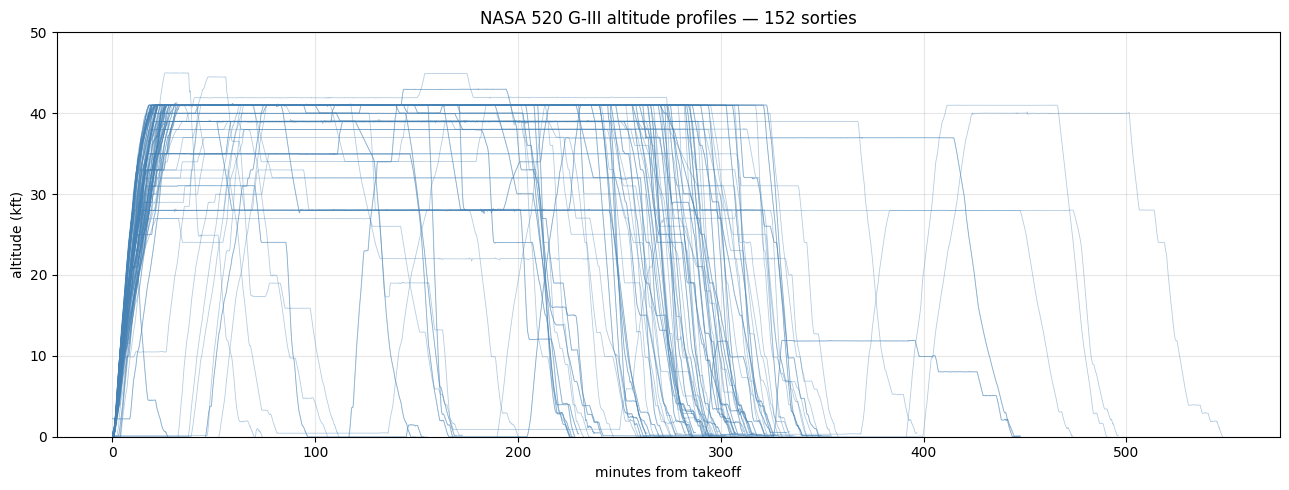

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
for name, a in sorties.items():
    t_min = (a["timestamp"] - a["timestamp"].iloc[0]).dt.total_seconds() / 60.0
    ax.plot(t_min, a["altitude"] / 1000, lw=0.6, alpha=0.4, color="steelblue")
ax.set_xlabel("minutes from takeoff")
ax.set_ylabel("altitude (kft)")
ax.set_title(f"NASA 520 G-III altitude profiles — {len(sorties)} sorties")
ax.grid(alpha=0.3)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


## 3. Ground tracks


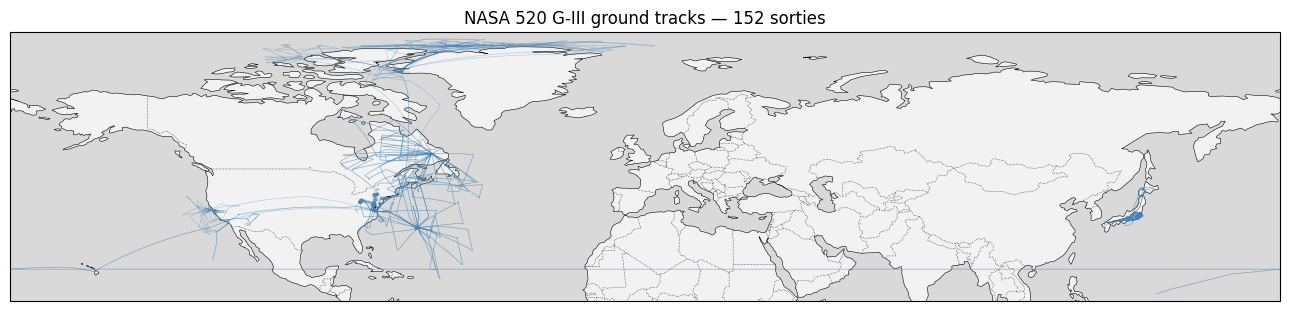

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="0.85")
ax.add_feature(cfeature.COASTLINE, lw=0.4)
ax.add_feature(cfeature.BORDERS, lw=0.4, ls=":")

for name, a in sorties.items():
    ax.plot(a["longitude"], a["latitude"], lw=0.4, alpha=0.4,
            color="steelblue", transform=ccrs.PlateCarree())

# Bound to the sortie footprint.
all_lat = pd.concat([a["latitude"] for a in sorties.values()])
all_lon = pd.concat([a["longitude"] for a in sorties.values()])
pad = 2
ax.set_extent([all_lon.min()-pad, all_lon.max()+pad,
               all_lat.min()-pad, all_lat.max()+pad])
ax.set_title(f"NASA 520 G-III ground tracks — {len(sorties)} sorties")
plt.tight_layout()
plt.show()


## 4. Climb / descent: per-altitude-bin medians

Same active-climb / active-descent definitions used for ER-2 phase 2:
restrict to fixes with VS > 1500 fpm (or < -1500 fpm for descent) so
the per-bin medians represent pure aircraft performance, not cruise
plateaus or weight-management holds the planner should model
separately via `typical_climb_out` if needed.


In [5]:
ACTIVE_VS_THR_FPM = 1500.0
BIN_FT = 5000

climb_bins   = per_bin(sorties, "climb",   +1, ACTIVE_VS_THR_FPM, bin_ft=BIN_FT,
                       extra_cols=("tas_kt", "mach"))
descent_bins = per_bin(sorties, "descent", -1, ACTIVE_VS_THR_FPM, bin_ft=BIN_FT,
                       extra_cols=("tas_kt", "mach"))

print("Active CLIMB (VS >= 1500 fpm):")
print(climb_bins.to_string(index=False))
print()
print("Active DESCENT (VS <= -1500 fpm):")
print(descent_bins.to_string(index=False))


Active CLIMB (VS >= 1500 fpm):
 alt_bin_ft     n  vs_med  vs_p25  vs_p75  tas_med  mach_med
      -5000    78  1720.1  1597.0  2083.6    168.0       0.3
          0 12680  2112.7  1807.0  2507.1    243.0       0.4
       5000 13836  2615.7  2183.8  2906.3    282.2       0.4
      10000 16427  2252.7  1915.6  2582.0    335.5       0.5
      15000 15061  2135.0  1829.7  2511.0    386.0       0.6
      20000 13991  1915.7  1700.2  2366.8    415.8       0.7
      25000 13758  1925.8  1701.2  2318.5    443.4       0.7
      30000 11804  1853.0  1665.6  2078.7    440.7       0.8
      35000  4398  1688.3  1577.3  1857.0    439.3       0.8
      40000   238  1840.3  1755.3  1917.0    430.5       0.8

Active DESCENT (VS <= -1500 fpm):
 alt_bin_ft     n  vs_med  vs_p25  vs_p75  tas_med  mach_med
          0  1988 -1777.5 -2032.2 -1625.6    259.1       0.4
       5000  9398 -1906.8 -2438.5 -1668.1    281.7       0.4
      10000 12102 -2155.3 -2661.9 -1800.7    333.4       0.5
      15000 11553 -

## 5. Climb_profile breakpoints

VerticalProfile points pinned at:

* SL through FL400: per 5-kft bin, the active-climb median from §4
  (n>=30/bin).
* FL450 (certified ceiling): a small residual rate (500 fpm) so the
  integration terminates cleanly if a planner asks for the certified
  ceiling.  This is *not* the regulatory service ceiling — FAR Part 25
  defines that at 500 fpm AT MTOW, which active-climb medians can't
  isolate without weight tagging — it's just a top-of-envelope
  anchor.


In [6]:
CEILING_FT     = 45000           # G-III certified ceiling
# Residual climb rate at the certified ceiling — the FL410 active-climb
# bin shows ~1100 fpm and the FL400 cruise-altitude bin sees no
# active-climb fixes (n=0), so we extrapolate to a small positive rate
# at the certified ceiling.  Not a regulatory definition (FAR Part 25
# service ceiling is 500 fpm at MTOW); just an anchor that lets the
# integration terminate if a planner asks for 45 kft.
CEILING_VS_FPM = 500.0

# Use the active-climb medians directly.  Don't enforce monotone-
# decreasing-from-SL: jets typically peak ROC near FL050-100 (limited
# below by 250-KCAS ATC procedures), so a clamp would push bins below
# their IQRs.  If the resulting profile shows wobble (small-sample
# bins), that's a separate decision and shouldn't be hidden in the
# calibration step.
fixed = []
for _, r in climb_bins.iterrows():
    if r["alt_bin_ft"] >= 0 and r["alt_bin_ft"] < CEILING_FT:
        fixed.append((int(r["alt_bin_ft"]), float(r["vs_med"])))
fixed.append((CEILING_FT, CEILING_VS_FPM))

print("climb_profile points (alt_ft, vs_fpm):")
for alt, vs in fixed:
    print(f"  ({alt:>5d}, {vs:6.0f})")


climb_profile points (alt_ft, vs_fpm):
  (    0,   2113)
  ( 5000,   2616)
  (10000,   2253)
  (15000,   2135)
  (20000,   1916)
  (25000,   1926)
  (30000,   1853)
  (35000,   1688)
  (40000,   1840)
  (45000,    500)


## 6. Descent_profile breakpoints

Same construction: per-bin medians of active descent VS, anchored at
top of approach (~300-500 ft AGL) and at cruise altitude.  The
planner will steepen this to fit short legs via
`descent_path_angle_max_deg=6.0` (same posture as the ER-2 v1.6).


In [7]:
# Use the active-descent medians directly.  Don't enforce monotone-
# increasing-with-altitude: descent VS typically peaks around FL150-200
# (where the aircraft descends near VMO in CAS), then declines in the
# upper levels (Mach-limited descent at constant M).  The previous
# monotone-from-SL clamp was forcing every bin above FL150 above its
# IQR and obscuring the real shape.
fixed_desc = []
for _, r in descent_bins.iterrows():
    if 0 <= r["alt_bin_ft"] < 45000:
        fixed_desc.append((int(r["alt_bin_ft"]), abs(float(r["vs_med"]))))
fixed_desc = sorted(fixed_desc)

print("descent_profile points (alt_ft, |vs|_fpm):")
for alt, vs in fixed_desc:
    print(f"  ({alt:>5d}, {vs:6.0f})")


descent_profile points (alt_ft, |vs|_fpm):
  (    0,   1778)
  ( 5000,   1907)
  (10000,   2155)
  (15000,   2492)
  (20000,   2425)
  (25000,   2365)
  (30000,   2481)
  (35000,   2088)
  (40000,   2007)


## 7. TAS schedules: climb / cruise / descent

Three independent TAS-vs-altitude schedules, derived from per-phase
medians of the same IWG1 fixes that drove the climb_profile and
descent_profile.  At the same altitude the three phases differ
materially — at FL300 cruise TAS is +39 kt over climb; at FL400 the
descent is +26 kt over climb — so a single schedule shared across
phases (or a fixed-offset derivation like
`_descent_schedule_from_cruise(cruise, 49)`) under-reads cruise TAS
during cruise and mis-models descent.


In [8]:
climb_tas   = tas_per_bin(sorties, ["climb"],   bin_ft=BIN_FT, n_min=50)
cruise_tas  = tas_per_bin(sorties, ["cruise"],  bin_ft=BIN_FT, n_min=50)
descent_tas = tas_per_bin(sorties, ["descent"], bin_ft=BIN_FT, n_min=50)

print("Climb TAS:")
print(climb_tas.to_string(index=False))
print()
print("Cruise TAS:")
print(cruise_tas.to_string(index=False))
print()
print("Descent TAS:")
print(descent_tas.to_string(index=False))


# Climb: SL rotation -> ceiling, climb-phase medians.  Anchor SL at
# rotation TAS (jet takeoff convention, ~150 kt) since the SL climb-
# phase bin is contaminated by takeoff-roll fixes still accelerating.
ROTATION_TAS_KT = 150
climb_pts = [(0, ROTATION_TAS_KT)] + schedule_pts(
    climb_tas, [10000, 20000, 30000, 40000], n_min=200
)

# Cruise: anchor only on the typical cruise band (FL250 - FL400).
# Below FL250 the cruise-phase bin is rarely actually cruise (mostly
# brief level-offs during step climbs); the bin medians there don't
# generalize to mission planning.
cruise_pts = schedule_pts(cruise_tas, [25000, 30000, 35000, 40000], n_min=200)

# Descent: low-altitude anchor at observed approach TAS, then
# descent-phase medians up to ceiling.
descent_pts = schedule_pts(descent_tas, [10000, 20000, 30000, 40000], n_min=200)
# Prepend an SL anchor at typical G-III descent-through-FL000 (~180 kt).
descent_pts = [(0, 180)] + descent_pts

print()
print("Climb schedule  (alt_ft, tas_kt):", climb_pts)
print("Cruise schedule (alt_ft, tas_kt):", cruise_pts)
print("Descent schedule(alt_ft, tas_kt):", descent_pts)



Climb TAS:
 alt_bin_ft     n  tas_med  mach_med
      -5000  2182    100.1       0.2
          0 19513    221.4       0.3
       5000 14322    282.4       0.4
      10000 17841    339.0       0.5
      15000 18279    387.4       0.6
      20000 22011    420.8       0.7
      25000 22958    447.1       0.7
      30000 27073    445.7       0.8
      35000 28876    439.3       0.8
      40000  9732    436.0       0.8

Cruise TAS:
 alt_bin_ft      n  tas_med  mach_med
      -5000  40695     35.0       0.0
          0  58220     35.0       0.0
       5000   5780    275.1       0.4
      10000   8560    381.8       0.6
      15000   3748    398.4       0.6
      20000  18004    371.9       0.6
      25000 129995    406.3       0.7
      30000  88522    472.0       0.8
      35000 393053    448.6       0.8
      40000 984273    455.1       0.8

Descent TAS:
 alt_bin_ft     n  tas_med  mach_med
      -5000  1035    125.2       0.2
          0 51014    179.2       0.3
       5000 27444    275.6

## 8. Bank-angle analysis

`max_bank_deg` sets the minimum turn radius the Dubins planner uses;
it should reflect the *operational maximum* the aircraft is willing
to use during survey-line transitions, not the typical-mix median.

The 40k turn-fix sample (|Roll| > 5°) is dominated by small in-cruise
course corrections, so its median understates the bank used during
real maneuvers.  Use p90 instead — it captures the operational
ceiling without touching the steep-turn / emergency envelope.


In [9]:
ROLL_GATE_DEG = 5.0
banks = []
for a in sorties.values():
    abs_roll = a["roll_deg"].abs()
    in_turn = abs_roll > ROLL_GATE_DEG
    banks.append(abs_roll[in_turn])
all_banks = pd.concat(banks).dropna()
print(f"n turn fixes: {len(all_banks):,}")
print(f"|Roll| median:  {all_banks.median():.1f}°")
print(f"|Roll| p75/p90: {all_banks.quantile(0.75):.1f}° / {all_banks.quantile(0.90):.1f}°")


n turn fixes: 258,504
|Roll| median:  17.9°
|Roll| p75/p90: 27.6° / 30.0°


## 9. Operational vs aircraft-intrinsic framing

The TOC, approach-speed, and per-sortie peak-altitude statistics
that follow describe **operational** behavior across this sortie
set: wall-clock time-to-FL400 includes pre-cruise level-offs, ATC
routing, and step climbs; per-sortie peaks reflect actual mission
profiles flown rather than the airframe service ceiling under
MTOW; approach TAS is the median final-approach speed for the
mission mix.  Aircraft-intrinsic performance (climb / descent /
cruise schedules in §5–§7, bank in §8) is what the planner
consumes; the §9b numbers are reviewer-facing context.


## 9b. TOC, approach speed, service ceiling

Empirical observations to feed the SourceRecord and the
`approach_speed` / `service_ceiling` parameters.


In [10]:
# TOC = takeoff -> first FL400 fix
toc = []
for a in sorties.values():
    above = a[a["altitude"] >= 40000]
    if not above.empty:
        toc.append((above["timestamp"].iloc[0] - a["timestamp"].iloc[0]).total_seconds() / 60.0)
toc_s = pd.Series(toc)

# Approach speed: TAS at the last fix above 200 ft AGL with VS < -300 fpm.
approach_tas = []
for a in sorties.values():
    floor = a["altitude"].min()
    sub = a[(a["altitude"] - floor < 1500) & (a["altitude"] - floor > 200)
            & (a["vertical_rate"] < -300)]
    if not sub.empty:
        approach_tas.append(sub["tas_kt"].median())
ap_s = pd.Series(approach_tas).dropna()

# Service ceiling: p99 of per-sortie peak altitudes.
peaks = pd.Series([a["altitude"].max() for a in sorties.values()])

print(f"TOC (takeoff -> FL400):  n={len(toc_s)}, median {toc_s.median():.1f} min, IQR {toc_s.quantile(.25):.1f}-{toc_s.quantile(.75):.1f}, range {toc_s.min():.1f}-{toc_s.max():.1f}")
print(f"Approach TAS:            n={len(ap_s)}, median {ap_s.median():.0f} kt, IQR {ap_s.quantile(.25):.0f}-{ap_s.quantile(.75):.0f}")
print(f"Per-sortie peak alt:     median {peaks.median():.0f} ft, p99 {peaks.quantile(0.99):.0f} ft, max {peaks.max():.0f} ft")


TOC (takeoff -> FL400):  n=119, median 23.5 min, IQR 19.2-27.8, range 16.5-423.9
Approach TAS:            n=150, median 139 kt, IQR 135-143
Per-sortie peak alt:     median 41014 ft, p99 44716 ft, max 44999 ft


## 10. Validate calibrated profiles against observed data

Overlay the proposed VerticalProfile breakpoints on the per-bin
medians + IQR shading.  No comparison line against the shipping
`NASA_GIII()` — every commit makes the two trivially identical, and
the IQR + medians alone tell the calibration story.


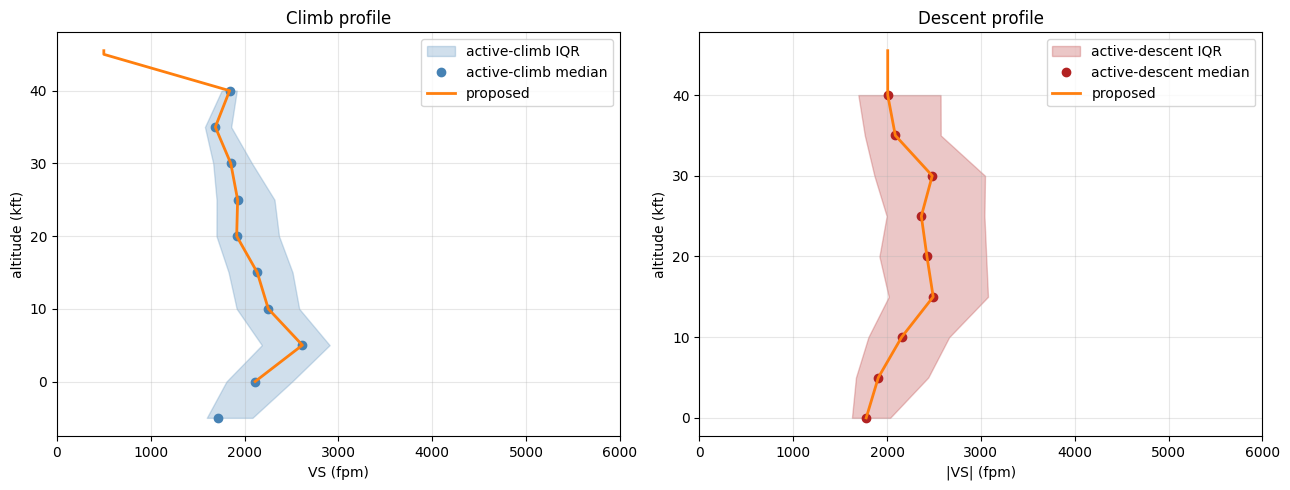

In [11]:
alt_grid = np.arange(0, 46000, 500)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.fill_betweenx(climb_bins["alt_bin_ft"]/1000,
                 climb_bins["vs_p25"], climb_bins["vs_p75"],
                 alpha=0.25, color="steelblue", label="active-climb IQR")
ax.plot(climb_bins["vs_med"], climb_bins["alt_bin_ft"]/1000,
        "o", color="steelblue", label="active-climb median")
ax.plot(evaluate_profile(fixed, alt_grid), alt_grid/1000,
        color="C1", lw=2, label="proposed")
ax.set_xlabel("VS (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Climb profile"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 6000)

ax = axes[1]
ax.fill_betweenx(descent_bins["alt_bin_ft"]/1000,
                 (-descent_bins["vs_p75"]).abs(),
                 (-descent_bins["vs_p25"]).abs(),
                 alpha=0.25, color="firebrick", label="active-descent IQR")
ax.plot((-descent_bins["vs_med"]).abs(), descent_bins["alt_bin_ft"]/1000,
        "o", color="firebrick", label="active-descent median")
ax.plot(evaluate_profile(fixed_desc, alt_grid), alt_grid/1000,
        color="C1", lw=2, label="proposed")
ax.set_xlabel("|VS| (fpm)"); ax.set_ylabel("altitude (kft)")
ax.set_title("Descent profile"); ax.legend(loc="upper right")
ax.grid(alpha=0.3); ax.set_xlim(0, 6000)

plt.tight_layout()
plt.show()


## 11. Code-paste-ready constructor block


In [12]:
print("# Paste into hyplan/aircraft/_models.py NASA_GIII.__init__")
print()
print("climb_profile=VerticalProfile(points=[")
for alt, vs in fixed:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)")
print("]),")
print()
print("descent_profile=VerticalProfile(points=[")
for alt, vs in fixed_desc:
    print(f"    ({alt:>5d} * ureg.feet, {vs:6.0f} * ureg.feet / ureg.minute),  # active-descent median (n>=30/bin)")
print("]),")
print()
print("climb_schedule=TasSchedule(points=[")
for alt, tas in climb_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # climb-phase median")
print("]),")
print()
print("cruise_schedule=TasSchedule(points=[")
for alt, tas in cruise_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # cruise-phase median")
print("]),")
print()
print("descent_schedule=TasSchedule(points=[")
for alt, tas in descent_pts:
    print(f"    ({alt:>5d} * ureg.feet, {tas:3d} * ureg.knot),  # descent-phase median")
print("]),")
print()
print(f"# Approach speed: median TAS during last-1500-ft descent across {len(ap_s)} sorties.")
print(f"approach_speed={int(round(ap_s.median()))} * ureg.knot,")
print()
print(f"# Service ceiling: p99 of per-sortie peak altitude across {len(sorties)} sorties.")
print(f"service_ceiling={int(round(peaks.quantile(0.99) / 1000) * 1000)} * ureg.feet,")
print()
print(f"# p90 |Roll| during turns ({len(all_banks):,} fixes, gate >5°) —")
print(f"# operational maximum, not the typical-mix median ({all_banks.median():.1f}°).")
print(f"turn_model=TurnModel(max_bank_deg={int(round(all_banks.quantile(0.90)))}.0),")
print()
print(f'sources=[SourceRecord(')
print(f'    source_type="iwg1",')
print(f'    reference="NASA 520 IWG1 calibration, n={len(sorties)} sorties",')
print(f'    confidence=0.85,')
print(f')],')


# Paste into hyplan/aircraft/_models.py NASA_GIII.__init__

climb_profile=VerticalProfile(points=[
    (    0 * ureg.feet,   2113 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    ( 5000 * ureg.feet,   2616 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (10000 * ureg.feet,   2253 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (15000 * ureg.feet,   2135 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (20000 * ureg.feet,   1916 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (25000 * ureg.feet,   1926 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (30000 * ureg.feet,   1853 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (35000 * ureg.feet,   1688 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (40000 * ureg.feet,   1840 * ureg.feet / ureg.minute),  # active-climb median (n>=30/bin)
    (45000 * ureg.feet,    500 * ureg.feet / ureg.minut